In [ ]:
# Import all required libraries
import os
import shutil
import glob
from pathlib import Path
from PIL import Image
import matplotlib.pyplot as plt
import numpy as np
import kagglehub

import torch
from torchvision import transforms, datasets
from torch.utils.data import DataLoader
from sklearn.model_selection import train_test_split

print("All libraries imported successfully!")
print(f"PyTorch Version: {torch.__version__}")

## Step 1: Download & Locate Dataset
We download the "Forest Fire, Smoke, and Non-Fire" dataset using `kagglehub` and examine its directory structure.

In [ ]:
# Download latest version of dataset
raw_dataset_path = kagglehub.dataset_download("amerzishminha/forest-fire-smoke-and-non-fire-image-dataset")

print("Path to downloaded dataset files:", raw_dataset_path)

# List sub-folders/files in the downloaded path
dataset_dir = Path(raw_dataset_path)

# If dataset contains a subfolder, traverse down to find image class folders
subfolders = [f for f in dataset_dir.glob('*') if f.is_dir()]
print("\nDetected directories inside dataset path:")
for folder in subfolders:
    print(f" - {folder.name}")

## Step 2: Data Cleaning & Integrity Verification
Before splitting or modeling, we verify that every image can be read properly and identify any corrupted or invalid files.

In [ ]:
# Supported image extensions
VALID_EXTENSIONS = ('.jpg', '.jpeg', '.png', '.bmp')

valid_image_paths = []
corrupted_files = []

# Scan through all directories and check image files
for root, _, files in os.walk(raw_dataset_path):
    for file in files:
        if file.lower().endswith(VALID_EXTENSIONS):
            full_path = os.path.join(root, file)
            try:
                # Test opening the image to detect corruption
                with Image.open(full_path) as img:
                    img.verify()  # Verify image header
                valid_image_paths.append(full_path)
            except Exception as e:
                print(f"Corrupted image detected & excluded: {full_path} | Error: {e}")
                corrupted_files.append(full_path)

print("\n--- Data Cleaning Summary ---")
print(f"Total Valid Images Found: {len(valid_image_paths)}")
print(f"Total Corrupted Files Removed: {len(corrupted_files)}")


--- Data Cleaning Summary ---
Total Valid Images Found: 41152
Total Corrupted Files Removed: 0


## Step 3: Exploratory Data Analysis (EDA) & Visualization
Here we inspect the class balance (number of images per class) and display sample images from each category.

--- Class Distribution Summary ---
 • Fire: 14,298 images
 • Non fire: 14,300 images
 • Smoke: 12,554 images


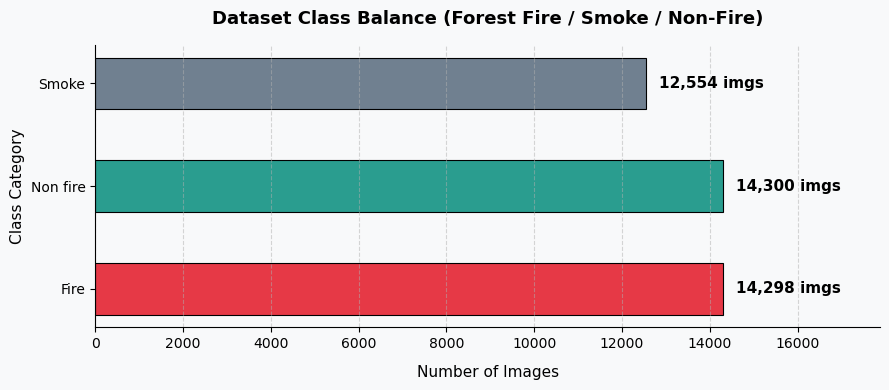

In [ ]:
from collections import defaultdict

# Group valid images by unique class name
class_counts = defaultdict(int)
unique_class_paths = {}

for file_path in dataset_dir.rglob('*'):
    if file_path.is_file() and file_path.suffix.lower() in VALID_EXTENSIONS:
        parent_name = file_path.parent.name.capitalize()
        class_counts[parent_name] += 1
        if parent_name not in unique_class_paths:
            unique_class_paths[parent_name] = file_path.parent

print("--- Class Distribution Summary ---")
for cname, count in class_counts.items():
    print(f" • {cname}: {count:,} images")

# Plotting Horizontal Bar Chart
plt.figure(figsize=(9, 4), facecolor='#f8f9fa')
categories = list(class_counts.keys())
values = list(class_counts.values())

bar_colors = ['#e63946', '#2a9d8f', '#708090']

bars = plt.barh(categories, values, color=bar_colors[:len(categories)], height=0.5, edgecolor='black', linewidth=0.8)

# Add text labels on the bars
for bar in bars:
    width = bar.get_width()
    plt.text(width + (max(values) * 0.02), bar.get_y() + bar.get_height()/2, 
             f'{width:,} imgs', va='center', ha='left', fontsize=11, fontweight='bold')

plt.title("Dataset Class Balance (Forest Fire / Smoke / Non-Fire)", fontsize=13, fontweight='bold', pad=15)
plt.xlabel("Number of Images", fontsize=11, labelpad=10)
plt.ylabel("Class Category", fontsize=11)
plt.xlim(0, max(values) * 1.25)

plt.gca().set_facecolor('#f8f9fa')
plt.gca().spines['top'].set_visible(False)
plt.gca().spines['right'].set_visible(False)
plt.grid(axis='x', linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

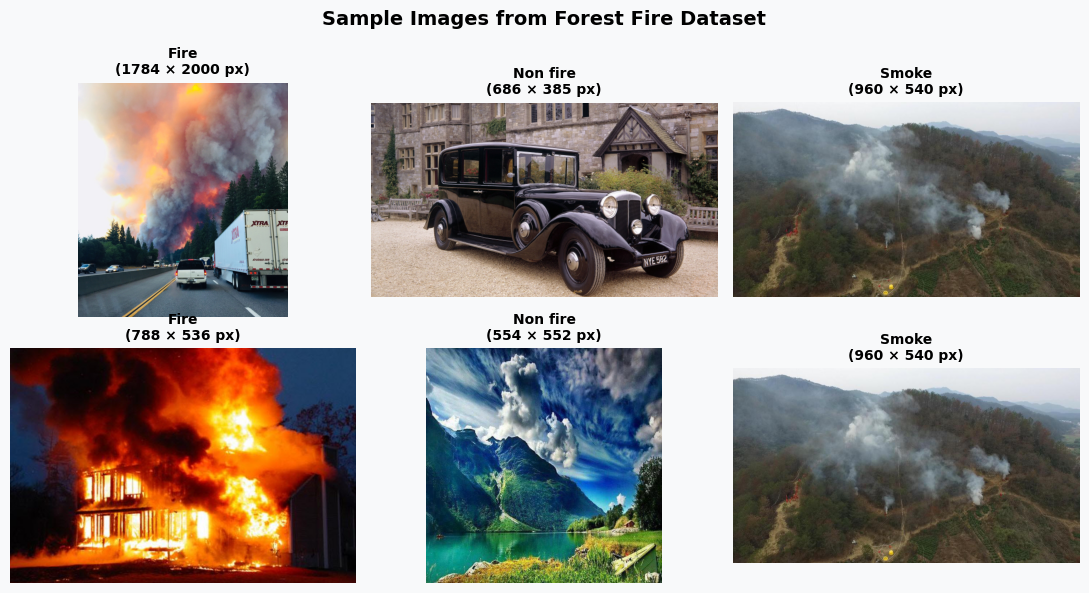

In [ ]:
# Visualizing 2 Sample Images per Class in a strict 3-Column Grid
classes = list(unique_class_paths.keys())
num_classes = len(classes)

fig, axes = plt.subplots(2, num_classes, figsize=(11, 6), facecolor='#f8f9fa')

for col_idx, cname in enumerate(classes):
    cfolder = unique_class_paths[cname]
    sample_images = [f for f in cfolder.glob('*.*') if f.suffix.lower() in VALID_EXTENSIONS][:2]
    
    for row_idx in range(2):
        ax = axes[row_idx, col_idx]
        
        if row_idx < len(sample_images):
            img_path = sample_images[row_idx]
            img = Image.open(img_path)
            
            ax.imshow(img)
            ax.set_title(f"{cname}\n({img.size[0]} × {img.size[1]} px)", 
                         fontsize=10, fontweight='bold', pad=6)
        
        ax.axis('off')

plt.suptitle("Sample Images from Forest Fire Dataset", fontsize=14, fontweight='bold', y=0.98)
plt.tight_layout()
plt.show()

## Step 4: Dataset Splitting (70% Train, 15% Validation, 15% Test)
We restructure the dataset into organized directories (`train`, `val`, `test`) to maintain clean separation for model training.

In [ ]:
import shutil
from sklearn.model_selection import train_test_split
from pathlib import Path

PROCESSED_DIR = Path("./data/processed")

# Split valid images into Train (70%), Val (15%), Test (15%)
train_paths, temp_paths = train_test_split(valid_image_paths, test_size=0.30, random_state=42)
val_paths, test_paths = train_test_split(temp_paths, test_size=0.50, random_state=42)

def copy_split(paths, split_name):
    for p in paths:
        class_name = Path(p).parent.name
        dest = PROCESSED_DIR / split_name / class_name
        dest.mkdir(parents=True, exist_ok=True)
        shutil.copy(p, dest / Path(p).name)

copy_split(train_paths, 'train')
copy_split(val_paths, 'val')
copy_split(test_paths, 'test')

print(f"Done! Split counts -> Train: {len(train_paths)} | Val: {len(val_paths)} | Test: {len(test_paths)}")

## Step 5: Preprocessing & Data Augmentation Pipeline
We define image transformations:
* **Training Set:** Resizing, Random Horizontal Flips, Random Rotation, Color Jitter, and Normalization (Augmentation).
* **Validation/Test Set:** Resizing and Normalization only (no spatial distortion).

In [ ]:
# Define Image Dimensions & Batch Size
from torchvision import transforms
from torchvision import datasets
from torch.utils.data import DataLoader
IMAGE_SIZE = (224, 224)
BATCH_SIZE = 32

# Training Augmentation & Preprocessing Pipeline
train_transforms = transforms.Compose([
    transforms.Resize(IMAGE_SIZE),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomRotation(degrees=15),
    transforms.ColorJitter(brightness=0.2, contrast=0.2),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

# Validation & Test Preprocessing Pipeline (No Random Augmentations)
eval_transforms = transforms.Compose([
    transforms.Resize(IMAGE_SIZE),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

# Create PyTorch ImageFolder Datasets
train_dataset = datasets.ImageFolder(
    root=str(PROCESSED_DIR / "train"),
    transform=train_transforms
)

val_dataset = datasets.ImageFolder(
    root=str(PROCESSED_DIR / "val"),
    transform=eval_transforms
)

test_dataset = datasets.ImageFolder(
    root=str(PROCESSED_DIR / "test"),
    transform=eval_transforms
)

# Build DataLoaders
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
val_loader   = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False)
test_loader  = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False)

print("DataLoaders prepared successfully!")
print(f"Total Batches in Train Loader: {len(train_loader)}")
print(f"Total Batches in Val Loader:   {len(val_loader)}")
print(f"Total Batches in Test Loader:  {len(test_loader)}")

## Step 6: Verify PyTorch DataLoaders & Augmented Batch
Finally, we sample a batch from `train_loader` and visualize normalized augmented outputs to confirm readiness for model training.

In [ ]:
# Helper function to un-normalize and display image tensor
def imshow_tensor(tensor_img, title=None):
    img = tensor_img.numpy().transpose((1, 2, 0))
    mean = np.array([0.485, 0.456, 0.406])
    std = np.array([0.229, 0.224, 0.225])
    img = std * img + mean  # Un-normalize
    img = np.clip(img, 0, 1)
    plt.imshow(img)
    if title:
        plt.title(title)
    plt.axis('off')

# Fetch 1 batch from train_loader
images, labels = next(iter(train_loader))
class_names = train_dataset.classes

# Display first 4 samples of the batch
plt.figure(figsize=(12, 4))
for i in range(min(4, len(images))):
    plt.subplot(1, 4, i + 1)
    imshow_tensor(images[i], title=f"Class: {class_names[labels[i]]}")
plt.tight_layout()
plt.show()